# OntoNotes 5 NER EDA
EDA for the OntoNotes 5 NER dataset in the Dataset folder. Plots are saved in the Images folder.

In [6]:
import json
import os
from collections import Counter
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd

DATASET_DIR = os.path.join("..", "Dataset")
IMAGES_DIR = os.path.join("..", "Images")
os.makedirs(IMAGES_DIR, exist_ok=True)

label_path = os.path.join(DATASET_DIR, "label.json")
with open(label_path, "r", encoding="utf-8") as f:
    label_to_id = json.load(f)
    id_to_label = {v: k for k, v in label_to_id.items()}

data_files = sorted(glob(os.path.join(DATASET_DIR, "train*.json")))
data_files += [
    os.path.join(DATASET_DIR, "valid.json"),
    os.path.join(DATASET_DIR, "test.json"),
]
data_files = [p for p in data_files if os.path.exists(p)]
data_files

['../Dataset/train00.json',
 '../Dataset/train01.json',
 '../Dataset/train02.json',
 '../Dataset/train03.json',
 '../Dataset/valid.json',
 '../Dataset/test.json']

In [7]:
records = []
for path in data_files:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            records.append(item)

num_sentences = len(records)
num_tokens = sum(len(r["tokens"]) for r in records)
num_sentences, num_tokens

(76714, 1388883)

In [8]:
def decode_labels(tag_ids):
    return [id_to_label[t] for t in tag_ids]

def iter_entities(tokens, tag_ids):
    labels = decode_labels(tag_ids)
    i = 0
    while i < len(labels):
        label = labels[i]
        if label.startswith("B-"):
            ent_type = label[2:]
            start = i
            i += 1
            while i < len(labels) and labels[i] == f"I-{ent_type}":
                i += 1
            end = i
            text = " ".join(tokens[start:end])
            yield ent_type, text, end - start
        else:
            i += 1

sentence_lengths = [len(r["tokens"]) for r in records]
tag_counter = Counter()
entity_type_counter = Counter()
entity_text_counter = Counter()
entity_span_lengths = []

for r in records:
    tag_counter.update(decode_labels(r["tags"]))
    for ent_type, text, span_len in iter_entities(r["tokens"], r["tags"]):
        entity_type_counter[ent_type] += 1
        entity_text_counter[text] += 1
        entity_span_lengths.append(span_len)

tag_counter.most_common(5)

[('O', 1198624),
 ('I-ORG', 22988),
 ('B-GPE', 19913),
 ('B-PERSON', 19437),
 ('I-DATE', 17153)]

Saved: ../Images/label_distribution_top25.png


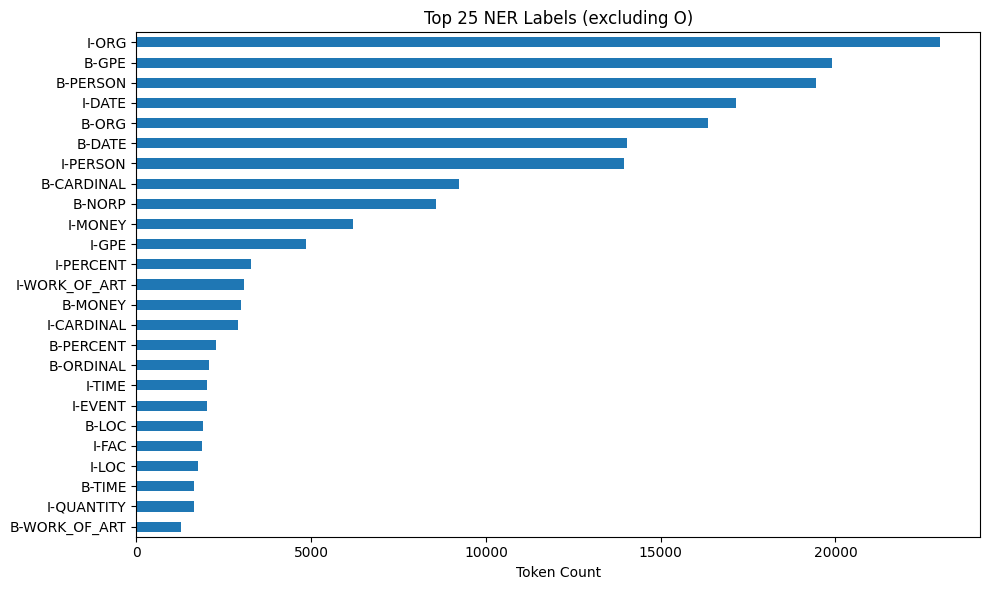

Saved: ../Images/sentence_length_distribution.png


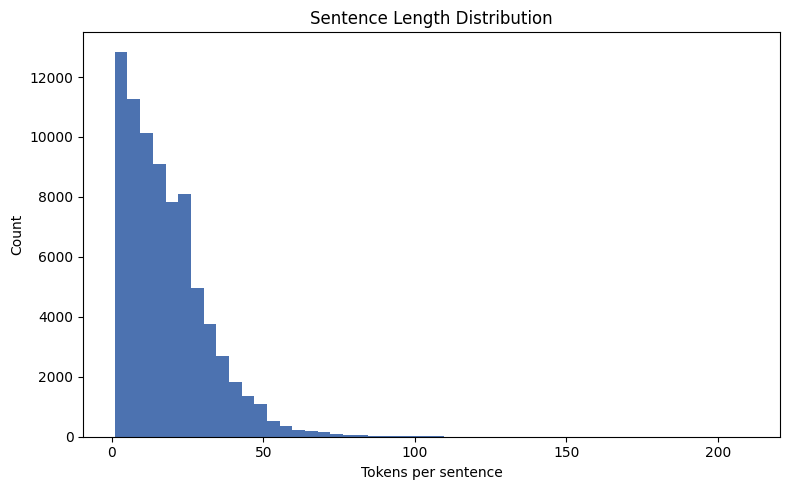

Saved: ../Images/entity_span_length_distribution.png


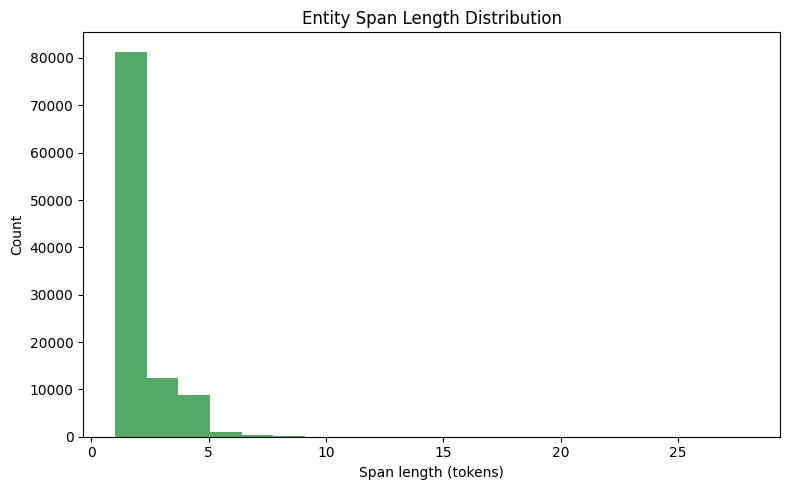

Saved: ../Images/top_entities.png


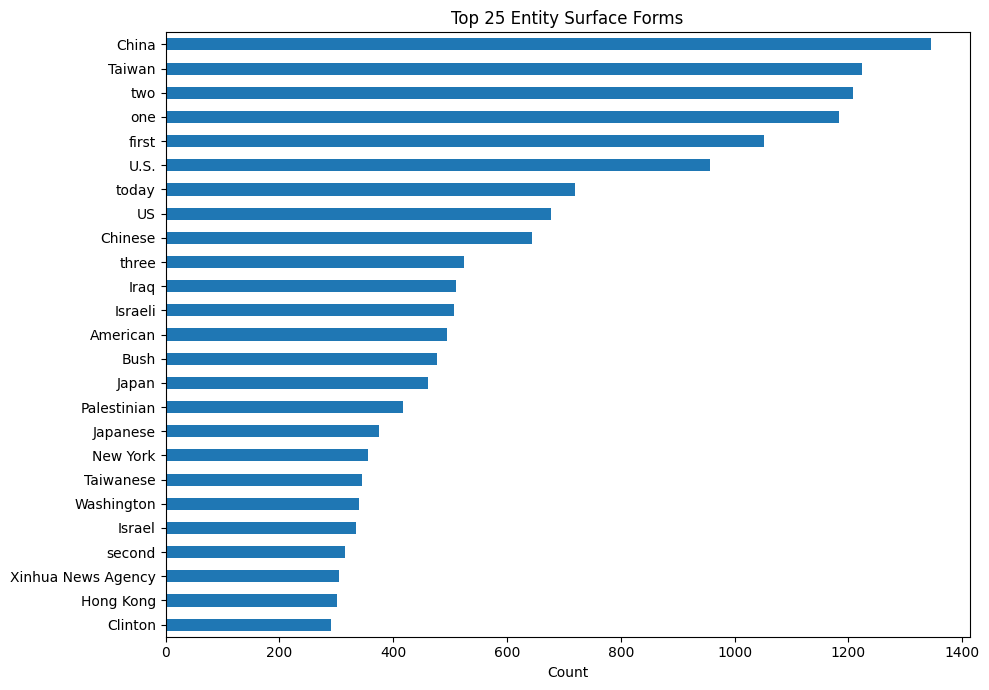

In [9]:
def save_plot(fig, filename):
    path = os.path.join(IMAGES_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    print(f"Saved: {path}")

# Label distribution (excluding O for readability)
label_counts = pd.Series(tag_counter).sort_values(ascending=False)
label_counts_no_o = label_counts.drop(labels=["O"], errors="ignore")

fig, ax = plt.subplots(figsize=(10, 6))
label_counts_no_o.head(25).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 25 NER Labels (excluding O)")
ax.set_xlabel("Token Count")
save_plot(fig, "label_distribution_top25.png")
plt.show()

# Sentence length distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sentence_lengths, bins=50, color="#4C72B0")
ax.set_title("Sentence Length Distribution")
ax.set_xlabel("Tokens per sentence")
ax.set_ylabel("Count")
save_plot(fig, "sentence_length_distribution.png")
plt.show()

# Entity span length distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(entity_span_lengths, bins=20, color="#55A868")
ax.set_title("Entity Span Length Distribution")
ax.set_xlabel("Span length (tokens)")
ax.set_ylabel("Count")
save_plot(fig, "entity_span_length_distribution.png")
plt.show()

# Top entity texts
top_entities = pd.Series(entity_text_counter).sort_values(ascending=False).head(25)
fig, ax = plt.subplots(figsize=(10, 7))
top_entities.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 25 Entity Surface Forms")
ax.set_xlabel("Count")
save_plot(fig, "top_entities.png")
plt.show()